## 1. Import Required Libraries

# MQTT to CSV Logger

This notebook subscribes to MQTT telemetry topics and appends readings to a CSV file. It supports multiple transport protocols (TCP, WebSockets) and optional Supabase integration.

**Installation:**
```
pip install paho-mqtt python-dotenv requests
```

**Configuration:**
Environment variables needed:
- `MQTT_URL`: MQTT broker URL (e.g., mqtt://host:1883 or mqtts://host:8883)
- `MQTT_USERNAME`: MQTT username
- `MQTT_PASSWORD`: MQTT password
- `MQTT_TOPIC_FILTER`: Topics to subscribe to (default: energy/+/+/telemetry)
- `SUPABASE_URL`: (optional) Supabase URL for data forwarding
- `SUPABASE_KEY`: (optional) Supabase API key

In [24]:
from __future__ import annotations
import os
import csv
import json
import time
import signal
import argparse
from pathlib import Path
from typing import Optional
from urllib.parse import urlparse

try:
    import paho.mqtt.client as mqtt
    from paho.mqtt.enums import CallbackAPIVersion
except Exception:
    raise SystemExit("Please install required package: pip install paho-mqtt")

try:
    import requests
except Exception:
    requests = None

try:
    from dotenv import load_dotenv
except ImportError:
    print('Warning: python-dotenv not installed. Install with: pip install python-dotenv')
    print('Falling back to system environment variables only.')
    load_dotenv = None

## 2. Set Environment Variables

In [25]:
import datetime

# ── ESP32 BMS MQTT Configuration ──
MQTT_URL          = 'mqtts://0d34f5789e1e4a669367abfe5bd45b15.s1.eu.hivemq.cloud:8883'
MQTT_USERNAME     = 'battery'
MQTT_PASSWORD     = 'Batterybms80'
MQTT_TOPIC_FILTER = 'battery/data'   # ESP32 publishes here every 5 s

# ── Cycle / Session labelling ──
CYCLE_NAME        = 'Cycle 01'       # change to "Cycle 02", "Cycle 03" etc.
BATTERY_ID        = 'b1'             # b1, b2, b3 …
SESSION_TYPE      = 'discharge'      # 'discharge' | 'charge' | 'idle'

# Auto-generate output path: <CYCLE_NAME>/<BATTERY_ID>_<SESSION_TYPE>.csv
_ts_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_CSV = f'{CYCLE_NAME}/{BATTERY_ID}_{SESSION_TYPE}.csv'

# Optional: Supabase (leave None to disable)
SUPABASE_URL = None
SUPABASE_KEY = None

print("═" * 45)
print("  ESP32 BMS — MQTT → CSV Logger")
print("═" * 45)
print(f"  Broker  : {MQTT_URL}")
print(f"  User    : {MQTT_USERNAME}")
print(f"  Topic   : {MQTT_TOPIC_FILTER}")
print(f"  Cycle   : {CYCLE_NAME}  ({SESSION_TYPE})")
print(f"  Battery : {BATTERY_ID}")
print(f"  Output  : {OUTPUT_CSV}")
print("═" * 45)


═════════════════════════════════════════════
  ESP32 BMS — MQTT → CSV Logger
═════════════════════════════════════════════
  Broker  : mqtts://0d34f5789e1e4a669367abfe5bd45b15.s1.eu.hivemq.cloud:8883
  User    : battery
  Topic   : battery/data
  Cycle   : Cycle 01  (discharge)
  Battery : b1
  Output  : Cycle 01/b1_discharge.csv
═════════════════════════════════════════════


## 3. Define MQTT Configuration and Constants

In [26]:
# CSV field names – matches ESP32 JSON payload from mqtt_manager.cpp
FIELDNAMES = [
    'ts', 'ts_iso', 'topic', 'device_type', 'device_id',
    'voltage', 'shunt_mV', 'current', 'power',
    'temperature',
    'soc_percent', 'soh_percent', 'uptime_ms', 'raw_payload'
]

# Global flag for graceful shutdown
stop_requested = False

def signal_handler(sig, frame):
    """Handle SIGINT and SIGTERM for graceful shutdown"""
    global stop_requested
    stop_requested = True
    print("\nShutdown requested...")

# Register signal handlers
signal.signal(signal.SIGINT, signal_handler)
signal.signal(signal.SIGTERM, signal_handler)


<function __main__.signal_handler(sig, frame)>

## 4. Parse Broker URL

In [27]:
def parse_broker_url(url: str):
    """
    Parse MQTT broker URL
    
    Returns:
        tuple: (host, port, scheme, path)
    
    Example:
        parse_broker_url('mqtt://localhost:1883') -> ('localhost', 1883, 'mqtt', '')
        parse_broker_url('mqtts://broker.example.com:8883') -> ('broker.example.com', 8883, 'mqtts', '')
    """
    if not url:
        return None, None, None, None
    
    p = urlparse(url)
    scheme = p.scheme
    host = p.hostname
    port = p.port
    path = p.path or ''
    
    return host, port, scheme, path


# Test the parse_broker_url function
test_url = "mqtts://broker.hivemq.cloud:8883"
host, port, scheme, path = parse_broker_url(test_url)
print(f"Parsed URL: {test_url}")
print(f"  Host: {host}, Port: {port}, Scheme: {scheme}, Path: {path}")

Parsed URL: mqtts://broker.hivemq.cloud:8883
  Host: broker.hivemq.cloud, Port: 8883, Scheme: mqtts, Path: 


## 5. Implement MQTTToCSV Class

In [28]:
class MQTTToCSV:
    """
    MQTT subscriber that logs ESP32 BMS telemetry to CSV.

    Supports TCP (mqtt/mqtts) and WebSocket (ws/wss) transports,
    TLS encryption, and optional Supabase forwarding.
    """

    def __init__(self, broker, port, scheme, path,
                 username, password, topic, outfile,
                 supabase_url=None, supabase_key=None):
        self.broker = broker
        self.port = port
        self.scheme = scheme
        self.path = path or ''
        self.username = username
        self.password = password
        self.topic = topic
        self.outfile = Path(outfile)
        self.supabase_url = supabase_url
        self.supabase_key = supabase_key
        self.msg_count = 0

        # Choose transport
        transport = 'websockets' if scheme in ('ws', 'wss') else 'tcp'
        self.client = mqtt.Client(
            callback_api_version=CallbackAPIVersion.VERSION2,
            transport=transport
        )
        self.client.on_connect = self.on_connect
        self.client.on_message = self.on_message

        if username:
            self.client.username_pw_set(username, password)

        # TLS for mqtts / wss / port 8883 / 8884
        if scheme in ('mqtts', 'wss') or port in (8883, 8884):
            try:
                self.client.tls_set()
                self.client.tls_insecure_set(True)   # skip CA check (dev)
            except Exception as e:
                print(f"TLS setup warning: {e}")

        if scheme in ('ws', 'wss') and self.path:
            try:
                self.client.ws_set_options(path=self.path)
            except Exception as e:
                print(f"WebSocket path warning: {e}")

        # Create CSV with header if it doesn't exist yet
        if not self.outfile.exists():
            with self.outfile.open('w', newline='', encoding='utf-8') as f:
                csv.DictWriter(f, fieldnames=FIELDNAMES).writeheader()
            print(f"Created CSV: {self.outfile}")

    # ── callbacks ────────────────────────────────────────────
    def on_connect(self, client, userdata, flags, reason_code, properties=None):
        print(f'MQTT connected  (rc={reason_code})')
        client.subscribe(self.topic)
        print(f'Subscribed to: {self.topic}')

    def on_message(self, client, userdata, msg):
        try:
            raw = msg.payload.decode('utf-8')
            try:
                p = json.loads(raw)
            except Exception:
                p = {}

            ts = int(time.time() * 1000)
            ts_iso = time.strftime('%Y-%m-%dT%H:%M:%S', time.localtime(ts / 1000))

            # Detect device info from topic  (battery/data → battery / esp32_bms)
            parts = msg.topic.split('/')
            if parts[0] == 'battery':
                device_type, device_id = 'battery', 'esp32_bms'
            elif len(parts) >= 3 and parts[0] == 'energy':
                device_type, device_id = parts[1], parts[2]
            else:
                device_type, device_id = parts[0], '/'.join(parts[1:])

            row = {
                'ts':          ts,
                'ts_iso':      ts_iso,
                'topic':       msg.topic,
                'device_type': device_type,
                'device_id':   device_id,
                'voltage':     p.get('bus_V',        p.get('voltage', '')),
                'shunt_mV':    p.get('shunt_mV',     ''),
                'current':     p.get('current_A',    p.get('current', '')),
                'power':       p.get('power_W',      p.get('power', '')),
                'temperature': p.get('temperature',  p.get('temp_c', '')),
                'soc_percent': p.get('soc_percent',  ''),
                'soh_percent': p.get('soh_percent',  ''),
                'uptime_ms':   p.get('uptime_ms',    ''),
                'raw_payload': raw
            }

            with self.outfile.open('a', newline='', encoding='utf-8') as f:
                csv.DictWriter(f, fieldnames=FIELDNAMES).writerow(row)

            self.msg_count += 1
            print(f'[{self.msg_count}] V={row["voltage"]}  I={row["current"]}  '
                  f'P={row["power"]}  T={row["temperature"]}°C  '
                  f'SoC={row["soc_percent"]}%  → {self.outfile.name}')

            # Optional Supabase forwarding
            if self.supabase_url and self.supabase_key:
                try:
                    self._send_to_supabase(p, row, msg.topic)
                except Exception as e:
                    print(f'Supabase upload failed: {e}')

        except Exception as e:
            print(f'Error processing message: {e}')

    # ── Supabase ─────────────────────────────────────────────
    def _send_to_supabase(self, p, row, topic):
        if requests is None:
            raise RuntimeError('pip install requests')
        data = {
            'ts': row['ts'], 'ts_iso': row['ts_iso'],
            'topic': topic,
            'device_type': row['device_type'],
            'device_id':   row['device_id'],
            'voltage':   p.get('bus_V')      or p.get('voltage'),
            'current':   p.get('current_A')  or p.get('current'),
            'power':     p.get('power_W')    or p.get('power'),
            'temperature': p.get('temperature'),
            'soc':       p.get('soc_percent'),
            'soh':       p.get('soh_percent'),
            'uptime_ms': p.get('uptime_ms'),
            'raw_payload': row['raw_payload']
        }
        url = self.supabase_url.rstrip('/') + '/rest/v1/telemetry'
        headers = {
            'apikey': self.supabase_key,
            'Authorization': f'Bearer {self.supabase_key}',
            'Content-Type': 'application/json',
            'Prefer': 'return=representation'
        }
        resp = requests.post(url, headers=headers, json=[data], timeout=10)
        if resp.status_code not in (200, 201):
            raise RuntimeError(f'{resp.status_code} {resp.text}')

    # ── main loop ────────────────────────────────────────────
    def run(self):
        global stop_requested
        if not self.broker:
            raise RuntimeError('No broker host')
        port = self.port or (8883 if self.scheme in ('mqtts', 'wss') else 1883)
        print(f'Connecting to {self.broker}:{port}  (scheme={self.scheme})')
        self.client.connect(self.broker, port, keepalive=60)
        try:
            while not stop_requested:
                self.client.loop(timeout=1.0)
        except KeyboardInterrupt:
            stop_requested = True
            print("\nInterrupted – shutting down…")
        finally:
            try:
                self.client.disconnect()
                print("Disconnected from broker")
            except Exception:
                pass


## 6. Execute Main Logic

In [29]:
# ── Build runtime config from variables above ──
config = {
    'broker':       MQTT_URL,
    'topic':        MQTT_TOPIC_FILTER,
    'username':     MQTT_USERNAME,
    'password':     MQTT_PASSWORD,
    'outfile':      OUTPUT_CSV,
    'supabase_url': SUPABASE_URL,
    'supabase_key': SUPABASE_KEY,
    # metadata stored in CSV filename but kept here for analysis cells
    'cycle_name':   CYCLE_NAME,
    'battery_id':   BATTERY_ID,
    'session_type': SESSION_TYPE,
}

print("=== MQTT → CSV Logger ===")
print(f"Broker  : {config['broker']}")
print(f"Topic   : {config['topic']}")
print(f"Output  : {config['outfile']}")
print(f"Session : {config['cycle_name']} / {config['battery_id']} / {config['session_type']}")
print(f"Supabase: {'Enabled' if config['supabase_url'] else 'Disabled'}")
print("=========================\n")


=== MQTT → CSV Logger ===
Broker  : mqtts://0d34f5789e1e4a669367abfe5bd45b15.s1.eu.hivemq.cloud:8883
Topic   : battery/data
Output  : Cycle 01/b1_discharge.csv
Session : Cycle 01 / b1 / discharge
Supabase: Disabled



In [23]:
# Parse broker URL and create service
broker_url = config['broker']
if '://' in broker_url:
    host, port, scheme, path = parse_broker_url(broker_url)
else:
    host = broker_url
    port = None
    scheme = None
    path = ''

# Ensure output directory exists
output_path = Path(config['outfile'])
output_path.parent.mkdir(parents=True, exist_ok=True)

# Create and run the MQTT to CSV service
service = MQTTToCSV(
    broker=host,
    port=port,
    scheme=scheme,
    path=path,
    username=config['username'],
    password=config['password'],
    topic=config['topic'],
    outfile=config['outfile'],
    supabase_url=config['supabase_url'],
    supabase_key=config['supabase_key']
)

print("Starting MQTT subscriber...")
print("(Press Ctrl+C to stop)\n")

try:
    service.run()
except KeyboardInterrupt:
    stop_requested = True
    print("\n\nShutdown requested (Ctrl+C). Waiting for cleanup...")
    try:
        service.client.disconnect()
        print("Disconnected from broker")
    except Exception:
        pass
except Exception as e:
    print(f"Error: {e}")

Starting MQTT subscriber...
(Press Ctrl+C to stop)

Connecting to 0d34f5789e1e4a669367abfe5bd45b15.s1.eu.hivemq.cloud:8883  (scheme=mqtts)
MQTT connected  (rc=Success)
Subscribed to: battery/data

Interrupted – shutting down…
Disconnected from broker


## 7. Data Analysis (Optional)

In [31]:
# ── 7a. Load & inspect collected data ───────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

outfile = Path(config['outfile'])

if not outfile.exists():
    print(f"CSV not found: {outfile}")
    print("Run the logger cell first to collect data from the ESP32.")
else:
    # Use Python engine + skip malformed rows (raw_payload JSON can confuse C parser)
    df = pd.read_csv(outfile, on_bad_lines='skip', engine='python')

    # Drop rows that are entirely NaN (blank separators)
    df.dropna(how='all', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── Parse timestamps ───────────────────────────────────────
    df['ts'] = pd.to_numeric(df['ts'], errors='coerce')
    df['datetime'] = pd.to_datetime(df['ts'], unit='ms', utc=True).dt.tz_localize(None)

    # ── Convert numeric columns ────────────────────────────────
    num_cols = ['voltage', 'current', 'power', 'temperature', 'soc_percent', 'soh_percent', 'uptime_ms']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # ── Duration ───────────────────────────────────────────────
    if len(df) >= 2:
        duration_s   = (df['ts'].max() - df['ts'].min()) / 1000
        duration_min = duration_s / 60
    else:
        duration_s = duration_min = 0

    # ── Energy (trapezoidal integration) ──────────────────────
    if 'power' in df.columns and df['power'].notna().sum() > 1:
        mask   = df['power'].notna()
        p_vals = df.loc[mask, 'power'].values
        t_ms   = df.loc[mask, 'ts'].values
        dt_h   = np.diff(t_ms) / 3_600_000
        energy_Wh  = float(np.sum((p_vals[:-1] + p_vals[1:]) / 2 * dt_h))
        avg_v      = df['voltage'].mean() if df['voltage'].notna().any() else 3.7
        energy_mAh = (energy_Wh / avg_v * 1000) if avg_v > 0 else 0
    else:
        energy_Wh = energy_mAh = 0

    # ── Print summary ─────────────────────────────────────────
    print("═" * 55)
    print(f"  Session  : {config.get('cycle_name','')} / {config.get('battery_id','')} / {config.get('session_type','')}")
    print(f"  File     : {outfile.name}")
    print(f"  Records  : {len(df)}")
    print(f"  Duration : {duration_min:.1f} min  ({duration_s:.0f} s)")
    if len(df):
        print(f"  Time     : {df['datetime'].min().strftime('%H:%M:%S')}  →  {df['datetime'].max().strftime('%H:%M:%S')}")
        print(f"  Devices  : {df['device_id'].unique().tolist()}")
    print("═" * 55)

    metrics = {
        'Voltage (V)':      'voltage',
        'Current (A)':      'current',
        'Power (W)':        'power',
        'Temperature (°C)': 'temperature',
        'SoC (%)':          'soc_percent',
        'SoH (%)':          'soh_percent',
    }
    print(f"  {'Metric':<20}  {'Min':>8}  {'Avg':>8}  {'Max':>8}  {'Std':>8}")
    print(f"  {'-'*20}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}")
    for label, col in metrics.items():
        if col in df.columns and df[col].notna().sum() > 0:
            s = df[col].dropna()
            print(f"  {label:<20}  {s.min():>8.3f}  {s.mean():>8.3f}  {s.max():>8.3f}  {s.std():>8.3f}")

    print("═" * 55)
    print(f"  Energy used  : {energy_Wh:.4f} Wh  ({energy_mAh:.1f} mAh)")

    soc_drop = df['soc_percent'].dropna()
    if len(soc_drop) >= 2:
        delta_soc = soc_drop.iloc[0] - soc_drop.iloc[-1]
        print(f"  SoC change   : {soc_drop.iloc[0]:.1f}% → {soc_drop.iloc[-1]:.1f}%  (Δ {delta_soc:.1f}%)")
    print("═" * 55)
    print(f"\nLast 5 rows:")
    display_cols = ['datetime', 'voltage', 'current', 'power', 'temperature', 'soc_percent']
    print(df[[c for c in display_cols if c in df.columns]].tail())


═══════════════════════════════════════════════════════
  Session  : Cycle 01 / b1 / discharge
  File     : b1_discharge.csv
  Records  : 12
  Duration : 0.9 min  (55 s)
  Time     : 12:10:36  →  12:11:31
  Devices  : ['esp32_bms']
═══════════════════════════════════════════════════════
  Metric                     Min       Avg       Max       Std
  --------------------  --------  --------  --------  --------
  SoC (%)                  0.000     0.000     0.000     0.000
  SoH (%)                  0.000     0.000     0.000     0.000
═══════════════════════════════════════════════════════
  Energy used  : 0.0000 Wh  (0.0 mAh)
  SoC change   : 0.0% → 0.0%  (Δ 0.0%)
═══════════════════════════════════════════════════════

Last 5 rows:
                  datetime  voltage  current  power  soc_percent
7  2026-02-28 12:11:11.029      NaN      NaN    NaN          0.0
8  2026-02-28 12:11:16.034      NaN      NaN    NaN          0.0
9  2026-02-28 12:11:21.036      NaN      NaN    NaN          0

## 8. Session Charts (Voltage · Current · Power · Temperature · SoC · SoH)

Chart saved → Cycle 01\b1_discharge.png


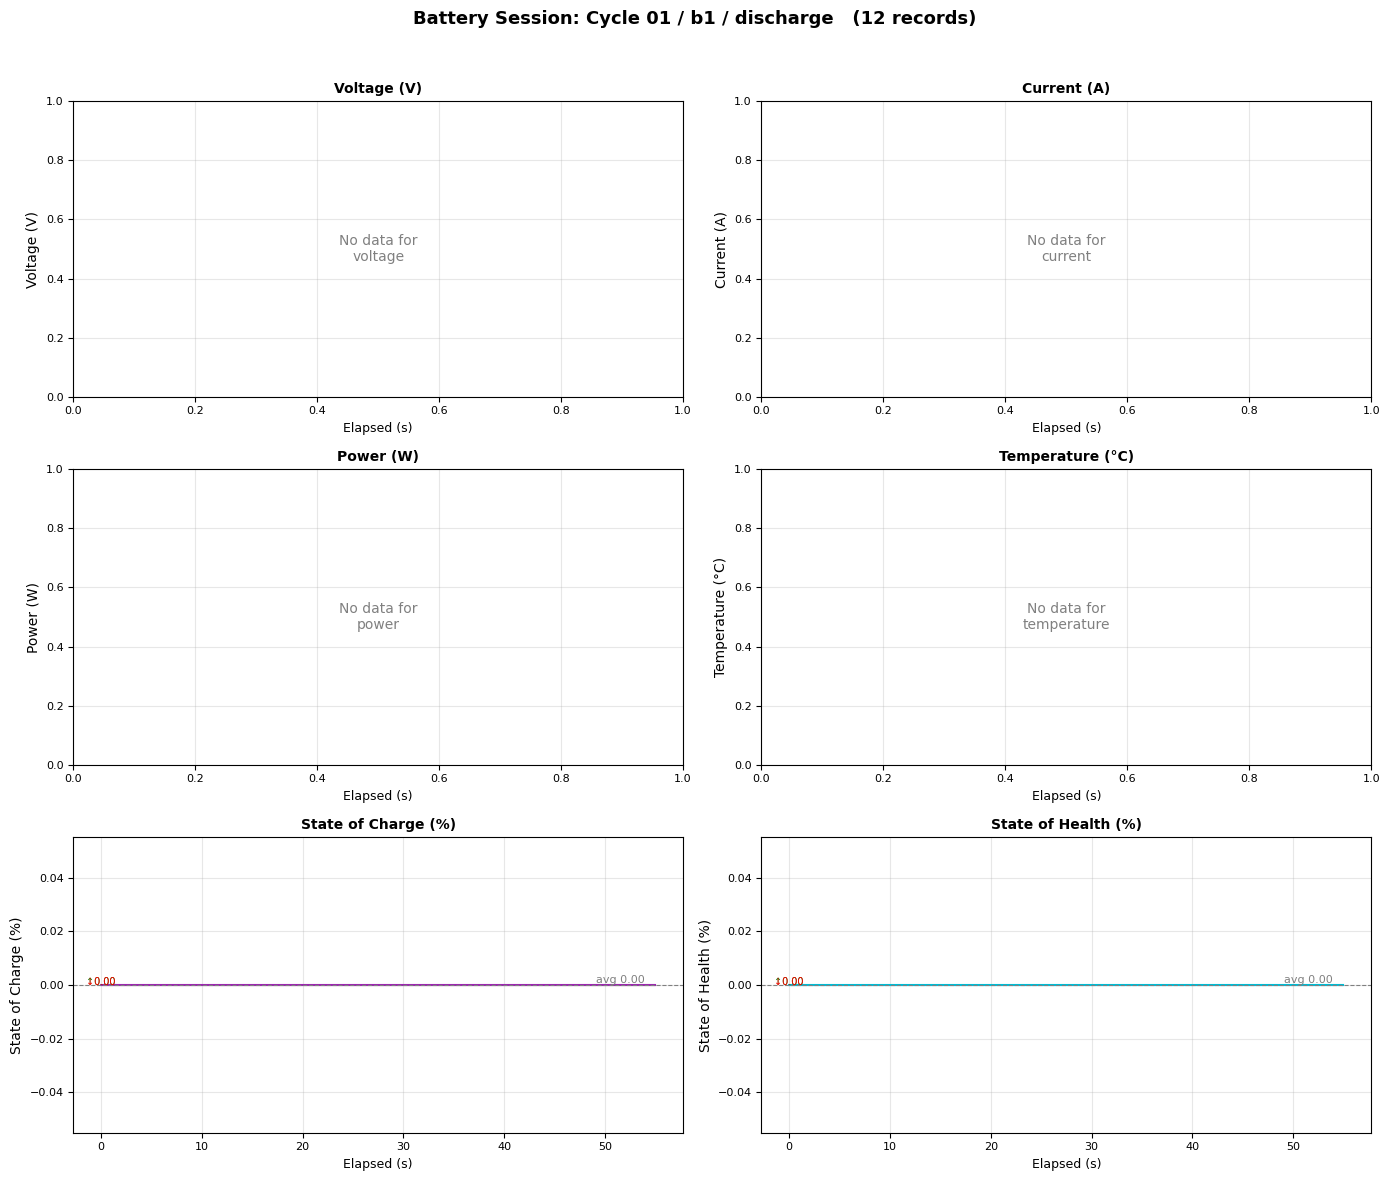

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

outfile = Path(config['outfile'])
if not outfile.exists():
    print("No data yet. Run the logger first.")
else:
    df = pd.read_csv(outfile, on_bad_lines='skip', engine='python')
    df.dropna(how='all', inplace=True)
    df['ts'] = pd.to_numeric(df['ts'], errors='coerce')
    for c in ['voltage','current','power','temperature','soc_percent','soh_percent']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # Elapsed time in seconds
    t0 = df['ts'].min()
    df['elapsed_s'] = (df['ts'] - t0) / 1000

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(
        f"Battery Session: {config.get('cycle_name','')} / {config.get('battery_id','')} / {config.get('session_type','')}   "
        f"({len(df)} records)", fontsize=13, fontweight='bold'
    )

    panels = [
        ('voltage',     'Voltage (V)',          '#2196F3', axes[0, 0]),
        ('current',     'Current (A)',           '#FF9800', axes[0, 1]),
        ('power',       'Power (W)',             '#4CAF50', axes[1, 0]),
        ('temperature', 'Temperature (°C)',      '#F44336', axes[1, 1]),
        ('soc_percent', 'State of Charge (%)',   '#9C27B0', axes[2, 0]),
        ('soh_percent', 'State of Health (%)',   '#00BCD4', axes[2, 1]),
    ]

    for col, ylabel, color, ax in panels:
        if col in df.columns and df[col].notna().sum() > 1:
            s = df[['elapsed_s', col]].dropna()
            ax.plot(s['elapsed_s'], s[col], color=color, linewidth=1.5)
            ax.fill_between(s['elapsed_s'], s[col], alpha=0.12, color=color)

            # Mean reference line
            mean_val = s[col].mean()
            ax.axhline(mean_val, color='gray', linewidth=0.8, linestyle='--')
            ax.text(s['elapsed_s'].max() * 0.98, mean_val,
                    f'avg {mean_val:.2f}', va='bottom', ha='right', fontsize=8, color='gray')

            # Min / Max annotations
            idx_max = s[col].idxmax()
            idx_min = s[col].idxmin()
            ax.annotate(f"↑{s.loc[idx_max, col]:.2f}",
                        xy=(s.loc[idx_max, 'elapsed_s'], s.loc[idx_max, col]),
                        fontsize=7, color='green', ha='center')
            ax.annotate(f"↓{s.loc[idx_min, col]:.2f}",
                        xy=(s.loc[idx_min, 'elapsed_s'], s.loc[idx_min, col]),
                        fontsize=7, color='red', ha='center')
        else:
            ax.text(0.5, 0.5, f'No data for\n{col}', transform=ax.transAxes,
                    ha='center', va='center', color='gray', fontsize=10)

        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlabel('Elapsed (s)', fontsize=9)
        ax.set_title(ylabel, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    chart_path = outfile.with_suffix('.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    print(f"Chart saved → {chart_path}")
    plt.show()


## 9. Battery Health Report

In [34]:
import numpy as np
import pandas as pd
from pathlib import Path

RATED_CAPACITY_mAh = 4200.0   # match config.h BATTERY_CAPACITY_mAh

def _col(df, name):
    """Return df[name] if the column exists and has data, else a Series of NaN."""
    if name in df.columns:
        return pd.to_numeric(df[name], errors='coerce')
    return pd.Series([float('nan')] * len(df))

outfile = Path(config['outfile'])
if not outfile.exists():
    print("No data yet.")
else:
    df = pd.read_csv(outfile, on_bad_lines='skip', engine='python')
    df.dropna(how='all', inplace=True)
    df['ts'] = pd.to_numeric(df['ts'], errors='coerce')

    voltage     = _col(df, 'voltage')
    current     = _col(df, 'current')
    power       = _col(df, 'power')
    soc         = _col(df, 'soc_percent')
    soh         = _col(df, 'soh_percent')
    temperature = _col(df, 'temperature')

    # ── Energy (trapezoidal) ──────────────────────────────────────
    if power.notna().sum() > 1:
        mask   = power.notna()
        p_vals = power[mask].values
        t_ms   = df.loc[mask, 'ts'].values
        dt_h   = np.diff(t_ms) / 3_600_000
        energy_Wh  = float(np.sum((p_vals[:-1] + p_vals[1:]) / 2 * dt_h))
        avg_v      = voltage.mean() if voltage.notna().any() else 3.7
        energy_mAh = (energy_Wh / avg_v * 1000) if avg_v > 0 else 0
    else:
        energy_Wh = energy_mAh = 0

    # ── SoC change ───────────────────────────────────────────────
    soc_vals  = soc.dropna()
    soc_start = soc_vals.iloc[0]  if len(soc_vals) else float('nan')
    soc_end   = soc_vals.iloc[-1] if len(soc_vals) else float('nan')
    delta_soc = (soc_start - soc_end) if not (np.isnan(soc_start) or np.isnan(soc_end)) else float('nan')

    # ── Estimated remaining runtime ──────────────────────────────
    avg_current_A = abs(current.mean()) if current.notna().any() else 0
    remaining_mAh = (soc_end / 100 * RATED_CAPACITY_mAh) if not np.isnan(soc_end) else 0
    est_runtime_min = (remaining_mAh / (avg_current_A * 1000)) * 60 if avg_current_A > 0 else 0

    # ── Temperature ───────────────────────────────────────────────
    max_temp = temperature.max() if temperature.notna().any() else float('nan')
    avg_temp = temperature.mean() if temperature.notna().any() else float('nan')
    temp_ok  = (max_temp < 45) if not np.isnan(max_temp) else True

    # ── SoH ──────────────────────────────────────────────────────
    soh_avg = soh.mean() if soh.notna().any() else float('nan')

    # ── Print report ─────────────────────────────────────────────
    def fmt(val, decimals=2, suffix=''):
        return f"{val:.{decimals}f}{suffix}" if not np.isnan(val) else "N/A"

    sep = "═" * 52
    print(sep)
    print("  BATTERY HEALTH REPORT")
    print(f"  Session : {config.get('cycle_name','')} / {config.get('battery_id','')} / {config.get('session_type','')}")
    print(sep)
    print(f"  {'Records collected':<30}: {len(df)}")
    if len(df) >= 2:
        dur_s   = (df['ts'].max() - df['ts'].min()) / 1000
        print(f"  {'Session duration':<30}: {dur_s/60:.1f} min  ({dur_s:.0f} s)")

    print()
    print("  -- Energy -------------------------------------------")
    print(f"  {'Energy consumed':<30}: {fmt(energy_Wh, 4)} Wh")
    print(f"  {'Capacity consumed (est.)':<30}: {fmt(energy_mAh, 1)} mAh")

    print()
    print("  -- State of Charge ----------------------------------")
    print(f"  {'Start SoC':<30}: {fmt(soc_start, 1)} %")
    print(f"  {'End SoC':<30}: {fmt(soc_end, 1)} %")
    print(f"  {'SoC drop':<30}: {fmt(delta_soc, 1)} %")
    print(f"  {'Remaining capacity':<30}: {remaining_mAh:.0f} mAh")
    print(f"  {'Est. remaining runtime':<30}: {est_runtime_min:.0f} min  @ {avg_current_A*1000:.0f} mA avg")

    print()
    print("  -- State of Health ----------------------------------")
    if not np.isnan(soh_avg):
        health_label = ("Good" if soh_avg >= 80 else "Degraded" if soh_avg >= 50 else "Poor")
        print(f"  {'Avg SoH (from ESP32)':<30}: {soh_avg:.1f}%  -> {health_label}")
    else:
        print(f"  {'SoH':<30}: N/A (INA219 data required)")

    print()
    print("  -- Temperature --------------------------------------")
    if not np.isnan(max_temp):
        temp_status = "Normal" if temp_ok else "HIGH -- check cooling!"
        print(f"  {'Max temperature':<30}: {max_temp:.1f} C  -> {temp_status}")
        print(f"  {'Avg temperature':<30}: {avg_temp:.1f} C")
    else:
        print(f"  {'Temperature':<30}: N/A (LM35 data required)")

    print()
    print("  -- Voltage ------------------------------------------")
    if voltage.notna().any():
        v_min = voltage.min()
        v_max = voltage.max()
        v_status = "Nominal" if v_min >= 3.0 else "LOW -- near cutoff!"
        print(f"  {'Voltage range':<30}: {v_min:.3f} V  ->  {v_max:.3f} V")
        print(f"  {'Min voltage status':<30}: {v_status}")
    else:
        print(f"  {'Voltage':<30}: N/A (INA219 data required)")
    print(sep)


════════════════════════════════════════════════════
  BATTERY HEALTH REPORT
  Session : Cycle 01 / b1 / discharge
════════════════════════════════════════════════════
  Records collected             : 12
  Session duration              : 0.9 min  (55 s)

  -- Energy -------------------------------------------
  Energy consumed               : 0.0000 Wh
  Capacity consumed (est.)      : 0.0 mAh

  -- State of Charge ----------------------------------
  Start SoC                     : 0.0 %
  End SoC                       : 0.0 %
  SoC drop                      : 0.0 %
  Remaining capacity            : 0 mAh
  Est. remaining runtime        : 0 min  @ 0 mA avg

  -- State of Health ----------------------------------
  Avg SoH (from ESP32)          : 0.0%  -> Poor

  -- Temperature --------------------------------------
  Temperature                   : N/A (LM35 data required)

  -- Voltage ------------------------------------------
  Voltage                       : N/A (INA219 data requ